# (7065) Fredschaaf: двухзонная астрометрия и звёздная PSF

Короткий отчёт поверх пакетного конвейера `reduce_series`: вычислительная логика находится в пакете, а здесь остаются диагностика и интерпретация.

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
from astropy.stats import sigma_clipped_stats
from astropy.wcs import FITSFixedWarning
from IPython.display import display

from fredschaaf_astrometry.ground import robust_upper_limit
from fredschaaf_astrometry.ground_pipeline import (
    reduce_series, write_reduction_outputs,
)
from fredschaaf_astrometry.series import load_series_config

warnings.simplefilter("ignore", FITSFixedWarning)
warnings.filterwarnings("ignore", message="The fit may not have converged")
warnings.filterwarnings("ignore", message="Input data contains invalid values")
plt.rcParams.update({"figure.figsize": (10, 6), "image.cmap": "gray"})

## 1. Единый запуск серии

Конфигурация определяет входные FITS, каталог Gaia, геометрию зон, параметры стеков и критерии качества. Та же функция вызывается из `scripts/reduce_ground_series.py`.

In [2]:
ROOT = Path.cwd()
CONFIG = load_series_config(ROOT / "configs" / "20250903_R.toml")
OUTPUT_DIR = ROOT / "outputs"

products = reduce_series(CONFIG)
output_paths = write_reduction_outputs(products, CONFIG, OUTPUT_DIR)

quality = products.frame_quality
control_oc = products.control_oc
distortion_samples = products.distortion_samples
stacks = products.stacks
stack_groups = products.stack_groups
comparison = products.comparison
summary = products.summary

print(f"Принято кадров: {quality.accepted.sum()} из {len(quality)}")
print(f"Построено стеков: {len(stacks)}")
print(f"Сохранено таблиц: {len(output_paths)}")

Принято кадров: 92 из 98
Построено стеков: 5
Сохранено таблиц: 6


## 2. Контроль качества кадров

Внешнее кольцо 4–10′ задаёт аффинную Gaia-привязку. Звёзды внутри 4′ не участвуют в ней и измеряют локальную покадровую поправку. Отбор кадров не использует положение астероида.

Медианный RMS внешней модели: 123.7 mas
Предел качества: 187.6 mas
Отброшено кадров: 6 из 98
Медианный RMS контрольных звёзд: 188.5 → 167.8 mas


,frame,outer_measured,outer_used,inner,outer_rms_mas,inner_rms_before_mas,inner_rms_after_mas,correction_xi_mas,correction_eta_mas
min,0.0,26.0,18.0,13.0,75.3,141.6,122.6,-182.0,-126.5
50%,48.5,28.0,23.0,14.0,123.7,188.5,167.8,-49.9,4.4
max,97.0,30.0,27.0,14.0,274.5,1094.8,1032.0,115.0,336.6


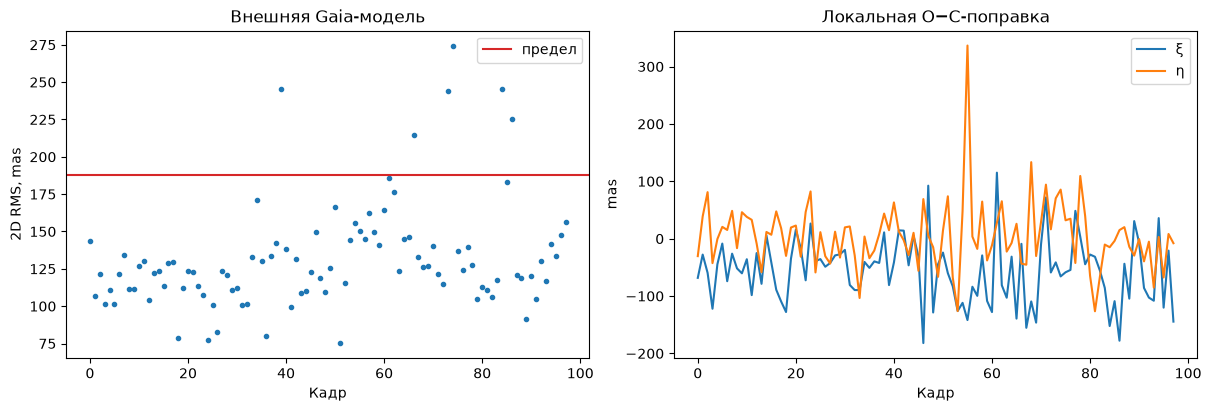

In [3]:
frame_rms_limit = robust_upper_limit(
    quality.outer_rms_mas,
    sigma=float(CONFIG.reduction["frame_rejection_sigma"]),
)
print(f"Медианный RMS внешней модели: {quality.outer_rms_mas.median():.1f} mas")
print(f"Предел качества: {frame_rms_limit:.1f} mas")
print(f"Отброшено кадров: {(~quality.accepted).sum()} из {len(quality)}")
print(
    "Медианный RMS контрольных звёзд: "
    f"{quality.inner_rms_before_mas.median():.1f} → "
    f"{quality.inner_rms_after_mas.median():.1f} mas"
)
display(quality.describe().loc[["min", "50%", "max"]].round(1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
axes[0].plot(quality.outer_rms_mas, ".")
axes[0].axhline(frame_rms_limit, color="tab:red", label="предел")
axes[0].set(xlabel="Кадр", ylabel="2D RMS, mas", title="Внешняя Gaia-модель")
axes[0].legend()
axes[1].plot(quality.correction_xi_mas, label="ξ")
axes[1].plot(quality.correction_eta_mas, label="η")
axes[1].set(xlabel="Кадр", ylabel="mas", title="Локальная O−C-поправка")
axes[1].legend()
plt.show()

## 3. Независимые стеки и эмпирическая PSF

Принятые кадры складываются пятью последовательными группами с компенсацией эфемеридного движения и локальной звёздной поправки. PSF каждой группы строится из ненасыщенных звёзд той же серии.

,group,frames,middle_utc,gaussian_xi_mas,gaussian_eta_mas,psf_xi_mas,psf_eta_mas,snr
0,1,20,2025-09-03T21:12:18.101,40.03,52.41,45.52,60.04,15.26
1,2,19,2025-09-03T21:17:27.855,-7.66,-25.55,-4.88,3.47,12.94
2,3,20,2025-09-03T21:22:28.807,54.62,-62.26,57.91,-17.10,13.76
3,4,17,2025-09-03T21:26:39.357,-6.83,5.36,-2.35,25.89,10.92
4,5,16,2025-09-03T21:30:42.522,97.48,0.97,111.29,34.65,9.91


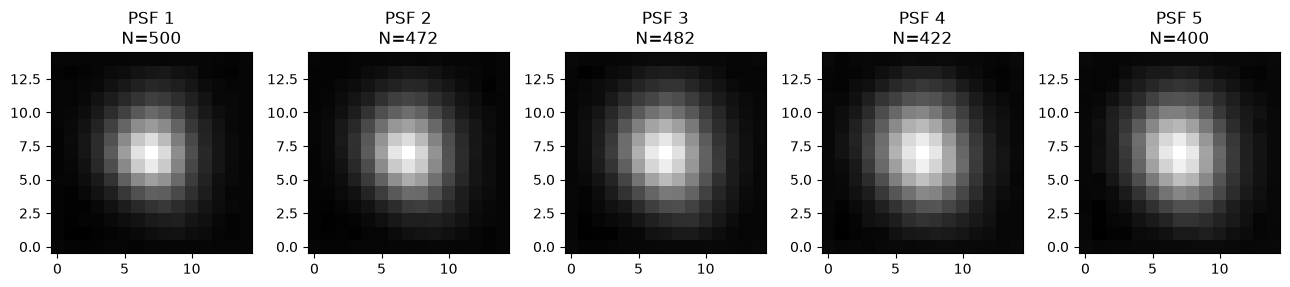

In [4]:
display(stacks[[
    "group", "frames", "middle_utc", "gaussian_xi_mas",
    "gaussian_eta_mas", "psf_xi_mas", "psf_eta_mas", "snr",
]].round(2))

fig, axes = plt.subplots(1, len(stack_groups), figsize=(13, 3))
for number, (group, ax) in enumerate(zip(stack_groups, axes), start=1):
    ax.imshow(group.psf, origin="lower")
    ax.set_title(f"PSF {number}\nN={group.psf_star_images}")
plt.tight_layout()
plt.show()

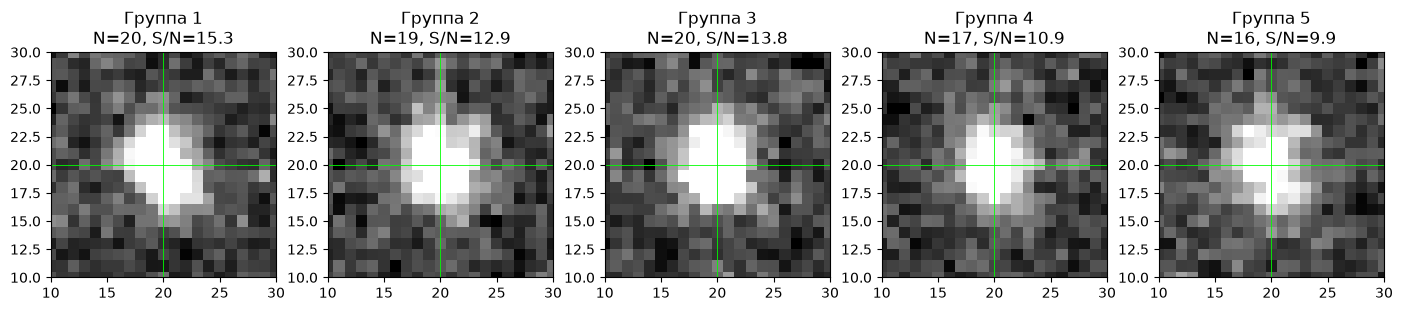

In [5]:
half = int(CONFIG.reduction["stack_half_size_px"])
fig, axes = plt.subplots(1, len(stack_groups), figsize=(14, 3.2))
for row, group, ax in zip(stacks.itertuples(), stack_groups, axes):
    _, background, noise = sigma_clipped_stats(group.image, sigma=3)
    ax.imshow(
        group.image, origin="lower",
        vmin=background - 2 * noise, vmax=background + 6 * noise,
    )
    ax.axvline(half, color="lime", linewidth=0.6)
    ax.axhline(half, color="lime", linewidth=0.6)
    ax.set_xlim(half - 10, half + 10)
    ax.set_ylim(half - 10, half + 10)
    ax.set_title(f"Группа {row.group}\nN={row.frames}, S/N={row.snr:.1f}")
plt.tight_layout()
plt.show()

## 4. Линейное движение и остатки

Для ξ и η используется общая временная сетка. Парные остатки сохраняют взаимный член ковариации центральной координаты.

,model,RMS_xi_mas,RMS_eta_mas,RMS_2D_mas,RMS_2D_n_minus_2_mas
0,Свободная гауссиана,36.6,35.8,51.2,66.1
1,Звёздная PSF,39.1,25.9,46.9,60.5


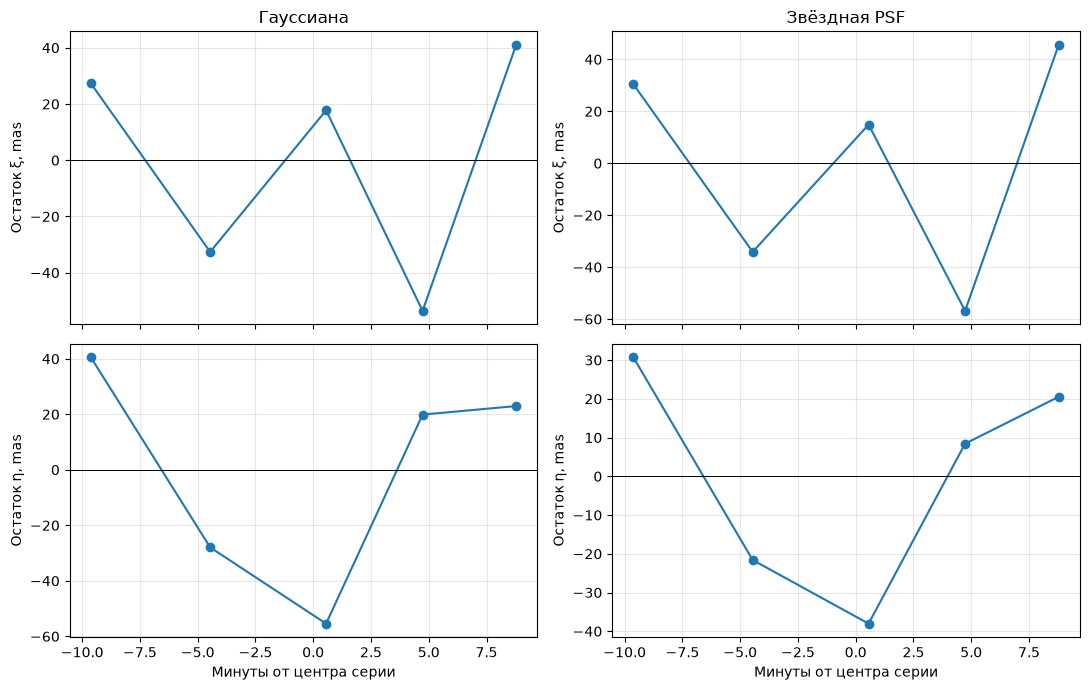

In [6]:
display(comparison.round(1))

fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True)
for column, (name, fit) in enumerate([
    ("Гауссиана", products.gaussian_fit),
    ("Звёздная PSF", products.psf_fit),
]):
    minutes = (stacks.middle_jd.to_numpy() - fit.reference_jd) * 1440.0
    axes[0, column].plot(minutes, fit.residuals_mas[:, 0], "o-")
    axes[1, column].plot(minutes, fit.residuals_mas[:, 1], "o-")
    axes[0, column].set_title(name)
    axes[0, column].set_ylabel("Остаток ξ, mas")
    axes[1, column].set_ylabel("Остаток η, mas")
    axes[1, column].set_xlabel("Минуты от центра серии")
    for row in range(2):
        axes[row, column].axhline(0, color="black", linewidth=0.7)
        axes[row, column].grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Итоговая координата

In [7]:
display(summary)

values = summary.set_index("quantity").value
print(f"Результат на {values.central_utc}")
print(f"RA  = {float(values.RA_deg):.8f}°")
print(f"Dec = {float(values.Dec_deg):.8f}°")
print(
    f"PSF RMS: ξ={products.psf_fit.rms_mas[0]:.1f}, "
    f"η={products.psf_fit.rms_mas[1]:.1f}, "
    f"2D={products.psf_fit.rms_2d_mas:.1f} mas"
)
print(
    "PSF 2D RMS с поправкой n−2: "
    f"{products.psf_fit.rms_2d_adjusted_mas:.1f} mas"
)

,quantity,value
0,central_utc,2025-09-03T21:21:55.329
1,RA_deg,43.487979
2,Dec_deg,15.440525
3,O-C_xi_mas,41.498551
4,O-C_eta_mas,21.389909
5,error_xi_mas,22.55387
6,error_eta_mas,14.940115
7,RMS_xi_mas,39.064449
8,RMS_eta_mas,25.877039
9,RMS_2D_mas,46.857788


Результат на 2025-09-03T21:21:55.329
RA  = 43.48797876°
Dec = 15.44052461°
PSF RMS: ξ=39.1, η=25.9, 2D=46.9 mas
PSF 2D RMS с поправкой n−2: 60.5 mas


## Вывод

Эмпирическая PSF использует реальную форму звёзд данного телескопа и данной группы кадров. Она уменьшает число свободных параметров слабого объекта и проверяет устойчивость результата относительно свободной гауссовой модели.

Выбор PSF-звёзд основан только на блеске, отсутствии насыщения и расстоянии от астероида. Кадры отбраковываются только по внешней Gaia-модели; положения и остатки астероида в отборе не участвуют.